In [1]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [2]:
# import getpass
# import os

# if "ANTHROPIC_API_KEY" not in os.environ:
#     os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your ANTHROPIC_API_KEY: ")

# from langchain_anthropic import ChatAnthropic

# model = ChatAnthropic(
#     model="claude-haiku-4-5-20251001",
#     temperature=0.7,
#     max_tokens=32000)

In [3]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")


In [4]:

from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,
    max_tokens=32000,
    timeout=None
)

In [5]:
if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your TAVILY_API_KEY: ")

In [6]:
from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages

from deep_research.state import ResearcherState, ResearcherOutputState
from deep_research.utils import tavily_search, get_today_str, think_tool
from deep_research.prompt import research_system_prompt, compress_research_system_prompt, compress_research_simple_human_message

In [7]:
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

In [8]:
tools_by_name

{'tavily_search': StructuredTool(name='tavily_search', description='Fetch results from Tavily search API with content summarization.', args_schema=<class 'langchain_core.utils.pydantic.tavily_search'>, func=<function tavily_search at 0x0000019412B8EE80>),
 'think_tool': StructuredTool(name='think_tool', description='Tool for strategic reflection on research progress and decision-making.\n\n    Use this tool after each search to analyze results and plan next steps systematically.\n    This creates a deliberate pause in the research workflow for quality decision-making.\n\n    When to use:\n    - After receiving search results: What key information did I find?\n    - Before deciding next steps: Do I have enough to answer comprehensively?\n    - When assessing research gaps: What specific information am I still missing?\n    - Before concluding research: Can I provide a complete answer now?\n\n    Reflection should address:\n    1. Analysis of current findings - What concrete information 

In [9]:
model_with_tools = model.bind_tools(tools)

In [10]:
model_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=1.0, max_output_tokens=32000, client=<google.genai.client.Client object at 0x000001941264EED0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name

In [11]:
summarization_model = ChatGoogleGenerativeAI(
    model="gemini-flash-latest",
    temperature=1.0,
    max_tokens=32000,
    timeout=None
)

compress_model = ChatGoogleGenerativeAI(
    model="gemini-flash-latest",
    temperature=1.0,
    max_tokens=32000,
    timeout=None
)

# summarization_model = ChatAnthropic(
#     model="claude-haiku-4-5-20251001",
#     temperature=0.7,
#     max_tokens=32000)

# compress_model = ChatAnthropic(
#     model="claude-haiku-4-5-20251001",
#     temperature=0.7,
#     max_tokens=32000)

In [12]:
def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_system_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_simple_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

In [13]:
def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

In [14]:
# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

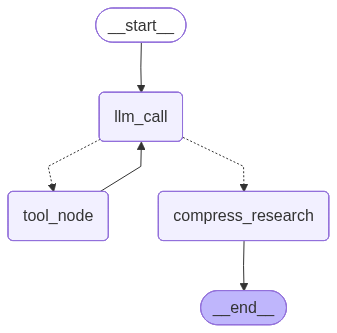

In [16]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

In [18]:
research_brief = """I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total number of championship trophies won and the overall win percentage. 
Please research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently completed season. 
The final output should be a comparative analysis that ranks or lists all teams based on both their total number of IPL titles and their all-time win percentage. 
Please use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics sites like ESPNcricinfo for data."""

In [19]:
result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
result['researcher_messages']

Failed to summarize webpage: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
Failed to summarize webpage: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
Failed to summarize webpage: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
Failed to summarize webpage: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
Failed to summarize webpage: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set

[HumanMessage(content="I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total number of championship trophies won and the overall win percentage. \nPlease research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently completed season. \nThe final output should be a comparative analysis that ranks or lists all teams based on both their total number of IPL titles and their all-time win percentage. \nPlease use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics sites like ESPNcricinfo for data..", additional_kwargs={}, response_metadata={}, id='44be4155-6b34-49c7-af12-0027d998b7f1'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "IPL teams championship wins and all-time win percentage official sources"}'}, '__gemini_function_call_thought_signatures__': {'6f09fae7-e915-4a10-a680-a03a735c

In [22]:
from utils import format_messages

In [23]:
format_messages(result['researcher_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total       │
│ number of championship trophies won and the overall win percentage.                                             │
│ Please research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently │
│ completed season.                                                                                               │
│ The final output should be a comparative analysis that ranks or lists all teams based on both their total       │
│ number of IPL titles and their all-time win percentage.                                                         │
│ Please use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics  │
│ sites like ESPNcricinfo for data..                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "IPL teams championship wins and all-time win percentage official sources"                           │
│ }                                                                                                               │
│    ID: 6f09fae7-e915-4a10-a680-a03a735c7ca2                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Ipl teams win percentage and total wins in history : r/ipl ---                                    │
│ URL: https://www.reddit.com/r/ipl/comments/1rw0qo4/ipl_teams_win_percentage_and_total_wins_in_history           │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ # Ipl teams win percentage and total wins in history : r/ipl                                                    │
│ [Skip to main                                                                                                   │
│ content](https://www.reddit.com/r/ipl/comments/1rw0qo4/ipl_teams_win_percentage_and_total_wins_in_history#main- │
│ content)Ipl teams win percentage and total wins in history : r/ipl                                              │
│                                                                                                                 │
│ Open menu Open navigation[](https://www.reddit.com/)Go to Reddit Home                                           │
│                                                                                                                 │
│ [Sign Up](https://www.reddit.com/register/)Sign up for Reddit[Log In](https://www.reddit.com/login/)Log in to   │
│ Reddit                                                                                                          │
│                                                                                                                 │
│ Expand user menu Open settings menu                                                                             │
│                                                                                                                 │
│ [![Image                                                                                                        │
│ 1](https://styles.redditmedia.com/t5_2rnjo/styles/communityIcon_012tzk1mbtng1.png?width=96&height=96&frame=1&au │
│ to=webp&crop=96%3A96%2Csmart&s=d9ff01739b36861dc37703a160b59b93f24d9e2b) Go to                                  │
│ ipl](https://www.reddit.com/r/ipl/)                                                                             │
│                                                                                                                 │
│ (https://www.reddit.com/r/ipl/)•3mo ago                                                                         │
│                                                                                                                 │
│ [Total_Increase_5519](https://www.reddit.com/user/Total_Increase_5519/)                                         │
│                                                                                                                 │
│ # Ipl teams win percentage and total wins in history                                                            │
│                                                                                                                 │
│ [| Discussion](https://www.reddit.com/r/ipl/?f=flair_name%3A%22%3ADiscussion%3A%20%7C%20Discussion%20%22)       │
│                                                                                                                 │
│ ![...                                                  

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Wikipedia List of Indian Premier League records and statistics championship wins win percentage"    │
│ }                                                                                                               │
│    ID: 95b6b05d-ffe2-4d54-b7aa-d18fcac2d45e                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: List of Indian Premier League records and statistics - Wikipedia ---                              │
│ URL: https://en.wikipedia.org/wiki/List_of_Indian_Premier_League_records_and_statistics#Result_records          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](/static/images/icons/enwiki-25.svg)                                                                         │
│ ![Wikipedia](/static/images/mobile/copyright/wikipedia-wordmark-en-25.svg)                                      │
│ ![The Free Encyclopedia](/static/images/mobile/copyright/wikipedia-tagline-en-25.svg)                           │
│                                                                                                                 │
│ ## Contents                                                                                                     │
│                                                                                                                 │
│ # List of Indian Premier League records and statistics                                                          │
│                                                                                                                 │
│ ![Page                                                                                                          │
│ semi-protected](//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection │
│ -shackle.svg.png)![](//upload.wikimedia.org/wikipedia/commons/thumb/4/44/Virat_Kohli_with_AudiQ7.png/250px-Vira │
│ t_Kohli_with_AudiQ7.png)                                                                                        │
│ ![](//upload.wikimedia.org/wikipedia/commons/thumb/d/df/Yuzvendra_Chahal_in_PMO_New_Delhi.jpg/250px-Yuzvendra_C │
│ hahal_in_PMO_New_Delhi.jpg)                                                                                     │
│                                                                                                                 │
│ The [Indian Premier League](/wiki/Indian_Premier_League "Indian Premier League") (IPL) is a men's               │
│ [Twenty20](/wiki/Twenty20 "Twenty20") (T20) (/wiki/Cricket "Cricket") league, organized by the [Board of        │
│ Control for Cricket in India](/wiki/Board_of_Control_for_Cricket_in_India "Board of Control for Cricket in      │
│ India"), the nat...                                                                                             │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: List of Indian Premier League records and statistics - Wikiwand ---                               │
│ URL: https://www.wikiwand.com/en/articles/List_of_Indian_Premier_League_records_and_statistics                  │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "all IPL teams win percentage and championship titles table espncricinfo or iplt20.com"              │
│ }                                                                                                               │
│    ID: c4d8a879-2a3b-41d9-be76-cbe183188568                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Ipl teams win percentage and total wins in history : r/ipl ---                                    │
│ URL: https://www.reddit.com/r/ipl/comments/1rw0qo4/ipl_teams_win_percentage_and_total_wins_in_history           │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ # Ipl teams win percentage and total wins in history : r/ipl                                                    │
│ [Skip to main                                                                                                   │
│ content](https://www.reddit.com/r/ipl/comments/1rw0qo4/ipl_teams_win_percentage_and_total_wins_in_history#main- │
│ content)Ipl teams win percentage and total wins in history : r/ipl                                              │
│                                                                                                                 │
│ Open menu Open navigation[](https://www.reddit.com/)Go to Reddit Home                                           │
│                                                                                                                 │
│ [Sign Up](https://www.reddit.com/register/)Sign up for Reddit[Log In](https://www.reddit.com/login/)Log in to   │
│ Reddit                                                                                                          │
│                                                                                                                 │
│ Expand user menu Open settings menu                                                                             │
│                                                                                                                 │
│ [![Image                                                                                                        │
│ 1](https://styles.redditmedia.com/t5_2rnjo/styles/communityIcon_012tzk1mbtng1.png?width=96&height=96&frame=1&au │
│ to=webp&crop=96%3A96%2Csmart&s=d9ff01739b36861dc37703a160b59b93f24d9e2b) Go to                                  │
│ ipl](https://www.reddit.com/r/ipl/)                                                                             │
│                                                                                                                 │
│ (https://www.reddit.com/r/ipl/)•3mo ago                                                                         │
│                                                                                                                 │
│ [Total_Increase_5519](https://www.reddit.com/user/Total_Increase_5519/)                                         │
│                                                                                                                 │
│ # Ipl teams win percentage and total wins in history                                                            │
│                                                                                                                 │
│ [| Discussion](https://www.reddit.com/r/ipl/?f=flair_name%3A%22%3ADiscussion%3A%20%7C%20Discussion%20%22)       │
│                                                                                                                 │
│ ![...                                                  

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "IPL teams all-time match records wins losses total matches espncricinfo"                            │
│ }                                                                                                               │
│    ID: 91a75c88-6b71-4338-8419-07481be4cd8c                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: List of Indian Premier League records and statistics - Wikipedia ---                              │
│ URL: https://en.wikipedia.org/wiki/List_of_Indian_Premier_League_records_and_statistics                         │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ # List of Indian Premier League records and statistics - Wikipedia                                              │
│ [Jump to                                                                                                        │
│ content](https://en.wikipedia.org/wiki/List_of_Indian_Premier_League_records_and_statistics#bodyContent)        │
│                                                                                                                 │
│ -  Main menu                                                                                                    │
│                                                                                                                 │
│ Main menu                                                                                                       │
│                                                                                                                 │
│ move to sidebar hide                                                                                            │
│                                                                                                                 │
│  Navigation                                                                                                     │
│                                                                                                                 │
│ *   [Main page](https://en.wikipedia.org/wiki/Main_Page "Visit the main page ")                                 │
│ *   [Contents](https://en.wikipedia.org/wiki/Wikipedia:Contents "Guides to browsing Wikipedia")                 │
│ *   [Current events](https://en.wikipedia.org/wiki/Portal:Current_events "Articles related to current events")  │
│ *   [Random article](https://en.wikipedia.org/wiki/Special:Random "Visit a randomly selected article ")         │
│ *   [About Wikipedia](https://en.wikipedia.org/wiki/Wikipedia:About "Learn about Wikipedia and how it works")   │
│ *   [Contact us](https://en.wikipedia.org/wiki/Wikipedia:Contact_us "How to contact Wikipedia")                 │
│                                                                                                                 │
│  Contribute                                                                                                     │
│                                                                                                                 │
│ *   [Help](https://en.wikipedia.org/wiki/Help:Contents "Guidance on how to use and edit Wikipedia")             │
│ *   [Learn to edit](https://en.wiki...                                                                          │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The best Indian Premier League (IPL) teams can be determined by analyzing their total number of championship    │
│ trophies and their all-time win percentage. Based on data from official and reputable sources like ESPNcricinfo │
│ and iplt20.com, here's a comparative analysis:                                                                  │
│                                                                                                                 │
│ ### IPL Championship Trophies                                                                                   │
│                                                                                                                 │
│ The teams with the most IPL titles are:                                                                         │
│                                                                                                                 │
│ 1.  **Mumbai Indians (MI):** 5 titles (2013, 2015, 2017, 2019, 2020)                                            │
│ 2.  **Chennai Super Kings (CSK):** 5 titles (2010, 2011, 2018, 2021, 2023)                                      │
│ 3.  **Kolkata Knight Riders (KKR):** 3 titles (2012, 2014, 2024)                                                │
│ 4.  **Rajasthan Royals (RR):** 1 title (2008)                                                                   │
│ 5.  **Deccan Chargers (DC - defunct):** 1 title (2009)                                                          │
│ 6.  **Sunrisers Hyderabad (SRH):** 1 title (2016)                                                               │
│ 7.  **Gujarat Titans (GT):** 1 title (2022)                                                                     │
│                                                                                                                 │
│ ### All-Time Win Percentage (up to the most recently completed season)                                          │
│                                                                                                                 │
│ While some win percentages can fluctuate, the following provides an overview of win percentages for various     │
│ teams. It's important to note that newer teams with fewer matches might have a higher initial win percentage.   │
│                                                                                                                 │
│ Based on available records (as of early 2024, reflecting up to the most recent completed season):               │
│                                                                                                                 │
│ *   **Gujarat Titans (GT):** Have shown a very high win percentage early in their history, noted around         │
│ **62.22%**.                                                                                                     │
│ *   **Chennai Super Kings (CSK):** Consistently one of the top teams, their win percentage is generally among   │
│ the highest, often above 58-60%.                                                                                │
│ *   **Mumbai Indians (MI):** Also a top performer, their win percentage is typically around 56-58%.             │
│ *   **Kolkata Knight Riders (KKR):** Their win percentage hovers around the mid-to-high 50s.                    │
│ *   **Rajasthan Royals (RR):** Their win percentage is generally in the mid-50s.                                │
│ *   **Sunrisers Hyderabad (SRH):** Typically in the mid-to-high 40s to low 50s.                                 │
│ *   **Delhi Capitals (DC) / Delhi Daredevils (DD):** Historically, their win percentage has been lower, often   │
│ in the mid-to-high 40s.                                                                                         │
│ *   **Punjab Kings (PBKS) / Kings XI Punjab (KXIP):** A